**0. Libs**

In [428]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing

**0.1. DataFrame**

In [429]:
df = pd.read_csv("data/raw/trading_synthetic_v2.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week.astype(int)

df_base = df.copy()
df_base["date"] = pd.to_datetime(df_base["date"])
df_base = df_base.sort_values("date")
df_base = df_base.set_index("date")

ts = df_base["contracts"].asfreq("W")
train = ts[:"2025-12-31"]
test = ts["2026-01-01":]

df_base.head()

,clients,product_type,commodity,operation_type,soy_price,corn_price,sugar_price,cotton_price,usd_brl,vol_soy,vol_corn,contracts,nf_volume,tons,year,month,week
date,,,,,,,,,,,,,,,,,
2023-01-01,514,origination,soy,spot,135.779097,91.415157,21.962264,86.550500,5.017673,0.032277,0.014794,3016,7540,542880,2023,1,52
2023-01-08,499,origination,soy,future,136.635433,91.496179,21.978981,85.552146,5.030720,0.007904,0.018034,3456,8640,622080,2023,1,1
2023-01-15,527,origination,corn,hedge,138.338781,93.969076,22.307239,86.536469,4.999192,0.036726,0.032063,2435,6087,438300,2023,1,2
2023-01-22,558,export,soy,future,139.769784,96.075485,21.799499,86.322480,5.028723,0.024190,0.045039,5545,32161,4713250,2023,1,3
2023-01-29,508,export,corn,spot,140.746871,95.776728,22.258365,86.273016,5.056324,0.012950,0.029736,2680,15544,2278000,2023,1,4


**1. Naive Forecast**

NAIVE MAPE: 153.86%


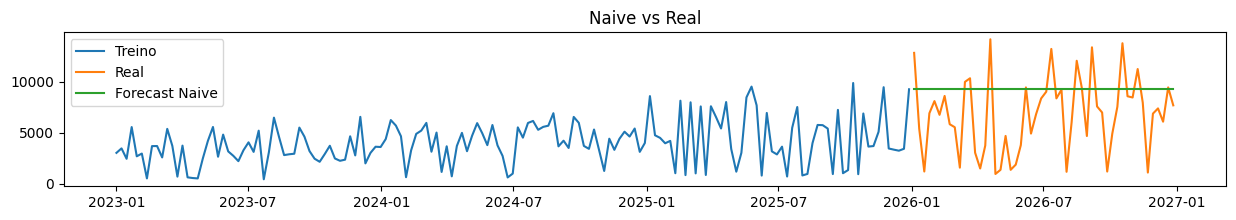

In [430]:
naive_forecast = train.iloc[-1]

naive_forecast = pd.Series([naive_forecast] * len(test), index=test.index)

naive_mape = np.mean(np.abs((test - naive_forecast) / test)) * 100
print(f"NAIVE MAPE: {naive_mape:.2f}%")

plt.figure(figsize=(15, 2))
plt.plot(train.index, train, label="Treino")
plt.plot(test.index, test, label="Real")
plt.plot(test.index, naive_forecast, label="Forecast Naive")

plt.legend()
plt.title("Naive vs Real")
plt.show()

**2. Holt-Winter Forecast**

HW MAPE: 96.90%


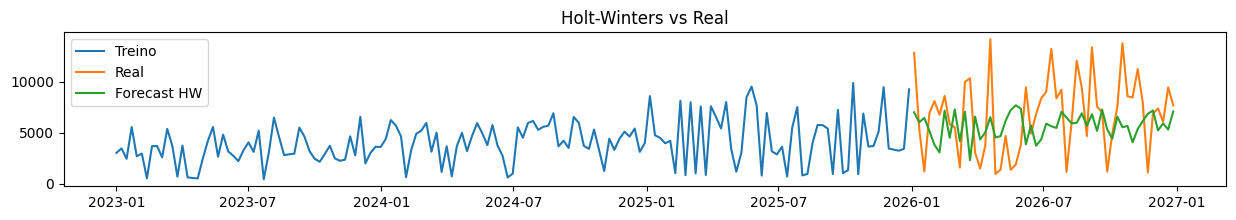

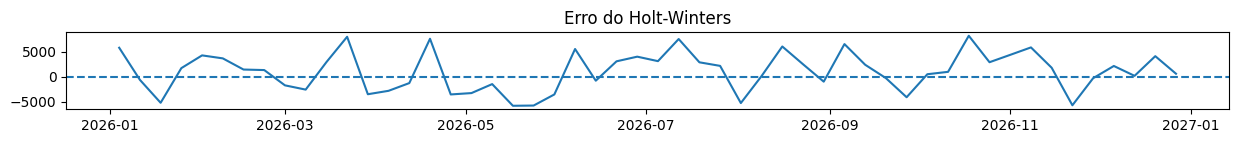

,real,forecast,erro_abs
2026-10-18,13765,5530.562841,8234.437159
2026-03-22,10331,2298.683822,8032.316178
2026-04-19,14153,6517.312825,7635.687175
2026-07-12,13206,5624.326488,7581.673512
2026-09-06,13366,6803.245423,6562.754577
2026-08-16,12046,5967.233703,6078.766297
2026-11-08,11234,5341.554206,5892.445794
2026-05-17,1353,7210.239273,5857.239273
2026-01-04,12820,6993.210534,5826.789466
2026-05-24,1864,7675.053330,5811.053330


In [431]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=52,
)

hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(len(test))

hw_mape = np.mean(np.abs((test - hw_forecast) / test)) * 100
print(f"HW MAPE: {hw_mape:.2f}%")

plt.figure(figsize=(15, 2))

plt.plot(train.index, train, label="Treino")
plt.plot(test.index, test, label="Real")
plt.plot(test.index, hw_forecast, label="Forecast HW")

plt.legend()
plt.title("Holt-Winters vs Real")
plt.show()

erro = test - hw_forecast

plt.figure(figsize=(15, 1))
plt.plot(test.index, erro)

plt.axhline(0, linestyle="--")

plt.title("Erro do Holt-Winters")
plt.show()

resultado = pd.DataFrame({"real": test, "forecast": hw_forecast})
resultado["erro_abs"] = abs(resultado["real"] - resultado["forecast"])
resultado.sort_values("erro_abs", ascending=False).head(10)

**3.0 - XGBoost Forecast**

In [432]:
df_base = pd.get_dummies(df_base, columns=["product_type", "commodity", "operation_type"], drop_first=False)

features = [
    "clients",
    "soy_price",
    "corn_price",
    "sugar_price",
    "cotton_price",
    "usd_brl",
    "vol_soy",
    "vol_corn",
    "year",
    "month",
    "week",
    "product_type_export",
    "product_type_origination",
    "commodity_corn",
    "commodity_soy",
    "commodity_sugar",
    "commodity_cotton",
    "operation_type_future",
    "operation_type_hedge",
]

target = "contracts"

xgb_train = df_base[df_base.index < "2026-01-01"]
xgb_test = df_base[df_base.index >= "2026-01-01"]

print(df_base.columns)

Index(['clients', 'soy_price', 'corn_price', 'sugar_price', 'cotton_price',
       'usd_brl', 'vol_soy', 'vol_corn', 'contracts', 'nf_volume', 'tons',
       'year', 'month', 'week', 'product_type_barter', 'product_type_export',
       'product_type_origination', 'commodity_corn', 'commodity_cotton',
       'commodity_soy', 'commodity_sugar', 'operation_type_future',
       'operation_type_hedge', 'operation_type_spot'],
      dtype='str')


XGB MAPE: 15.35%


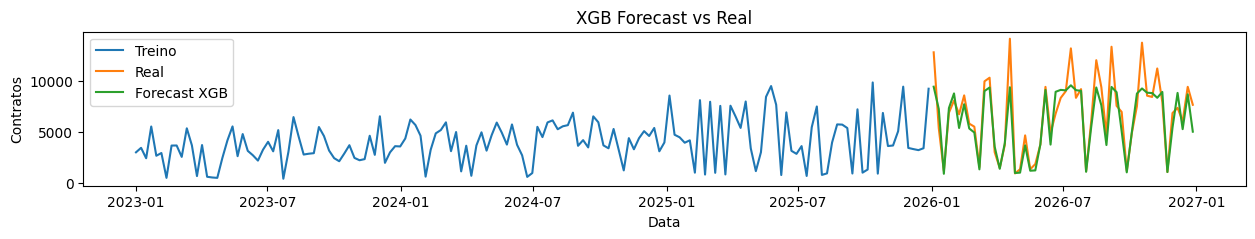

In [433]:
xgb_model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)

xgb_model.fit(xgb_train[features], xgb_train[target])

xgb_forecast = xgb_model.predict(xgb_test[features])

pred = xgb_model.predict(xgb_test[features])
xbg_mape = np.mean(np.abs((xgb_test[target] - pred) / xgb_test[target])) * 100
print(f"XGB MAPE: {xbg_mape:.2f}%")

plt.figure(figsize=(15, 2))
plt.plot(xgb_train.index, xgb_train[target], label="Treino")
plt.plot(xgb_test.index, xgb_test[target], label="Real")
plt.plot(xgb_test.index, xgb_forecast, label="Forecast XGB")

plt.xlabel("Data")
plt.ylabel("Contratos")
plt.title("XGB Forecast vs Real")

plt.legend()
plt.show()

In [434]:
importance = pd.DataFrame({"feature": features, "importance": xgb_model.feature_importances_})
importance.sort_values("importance", ascending=False)

,feature,importance
15,commodity_sugar,0.331010
14,commodity_soy,0.319054
13,commodity_corn,0.187039
0,clients,0.042141
11,product_type_export,0.040250
8,year,0.022028
16,commodity_cotton,0.010922
17,operation_type_future,0.009963
12,product_type_origination,0.009818
1,soy_price,0.006075


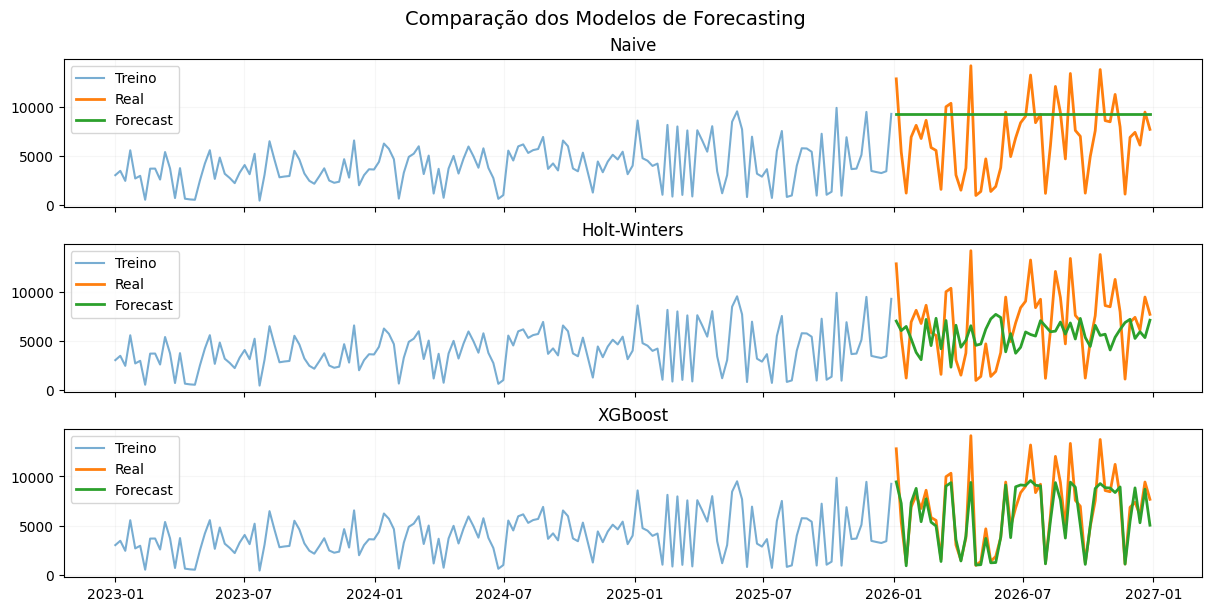

In [463]:
# Comparação dos modelos
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True, constrained_layout=True)


def plot_model(ax, title, forecast):
    ax.plot(train.index, train, label="Treino", alpha=0.6)
    ax.plot(test.index, test, label="Real", linewidth=2)
    ax.plot(test.index, forecast, label="Forecast", linewidth=2)

    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.1)

fig.suptitle("Comparação dos Modelos de Forecasting", fontsize=14)
plot_model(axes[0], "Naive", naive_forecast)
plot_model(axes[1], "Holt-Winters", hw_forecast)
plot_model(axes[2], "XGBoost", xgb_forecast)

plt.show()